In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
np.random.seed(42)
n_customers = 300

data = {
    'Annual_Income': np.random.normal(50000, 15000, n_customers),
    'Spending_Score': np.random.normal(50, 25, n_customers),
    'Age': np.random.normal(40, 12, n_customers),
    'Purchase_Frequency': np.random.normal(10, 5, n_customers)
}

df = pd.DataFrame(data)

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [4]:
k_values = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))


Text(0.5, 1.0, 'Elbow Method')

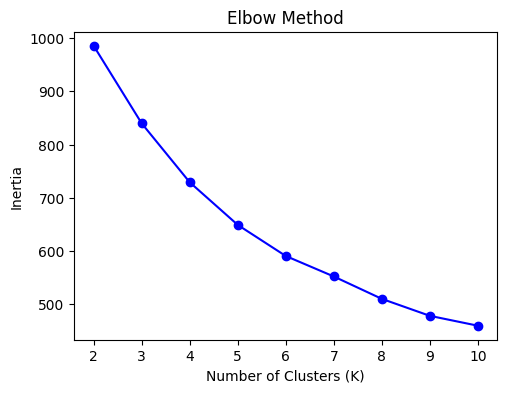

In [5]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, 'bo-')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

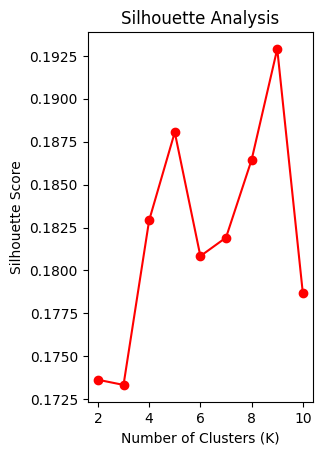

In [6]:
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, 'ro-')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()



In [7]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

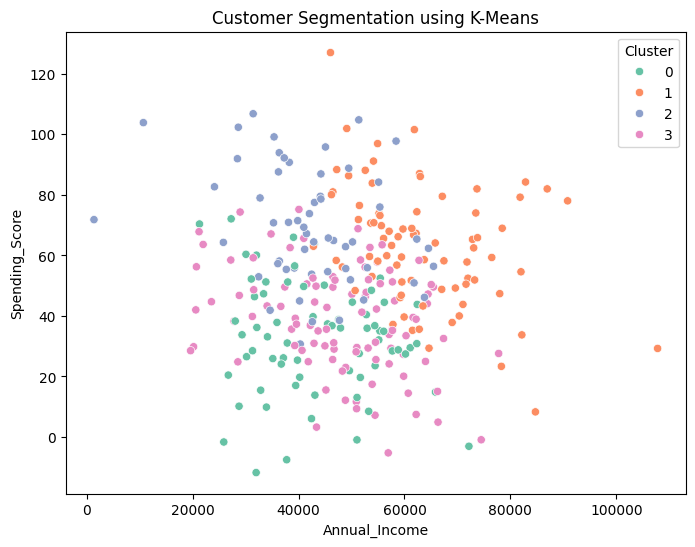

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df['Annual_Income'],
    y=df['Spending_Score'],
    hue=df['Cluster'],
    palette='Set2'
)
plt.title("Customer Segmentation using K-Means")
plt.show()

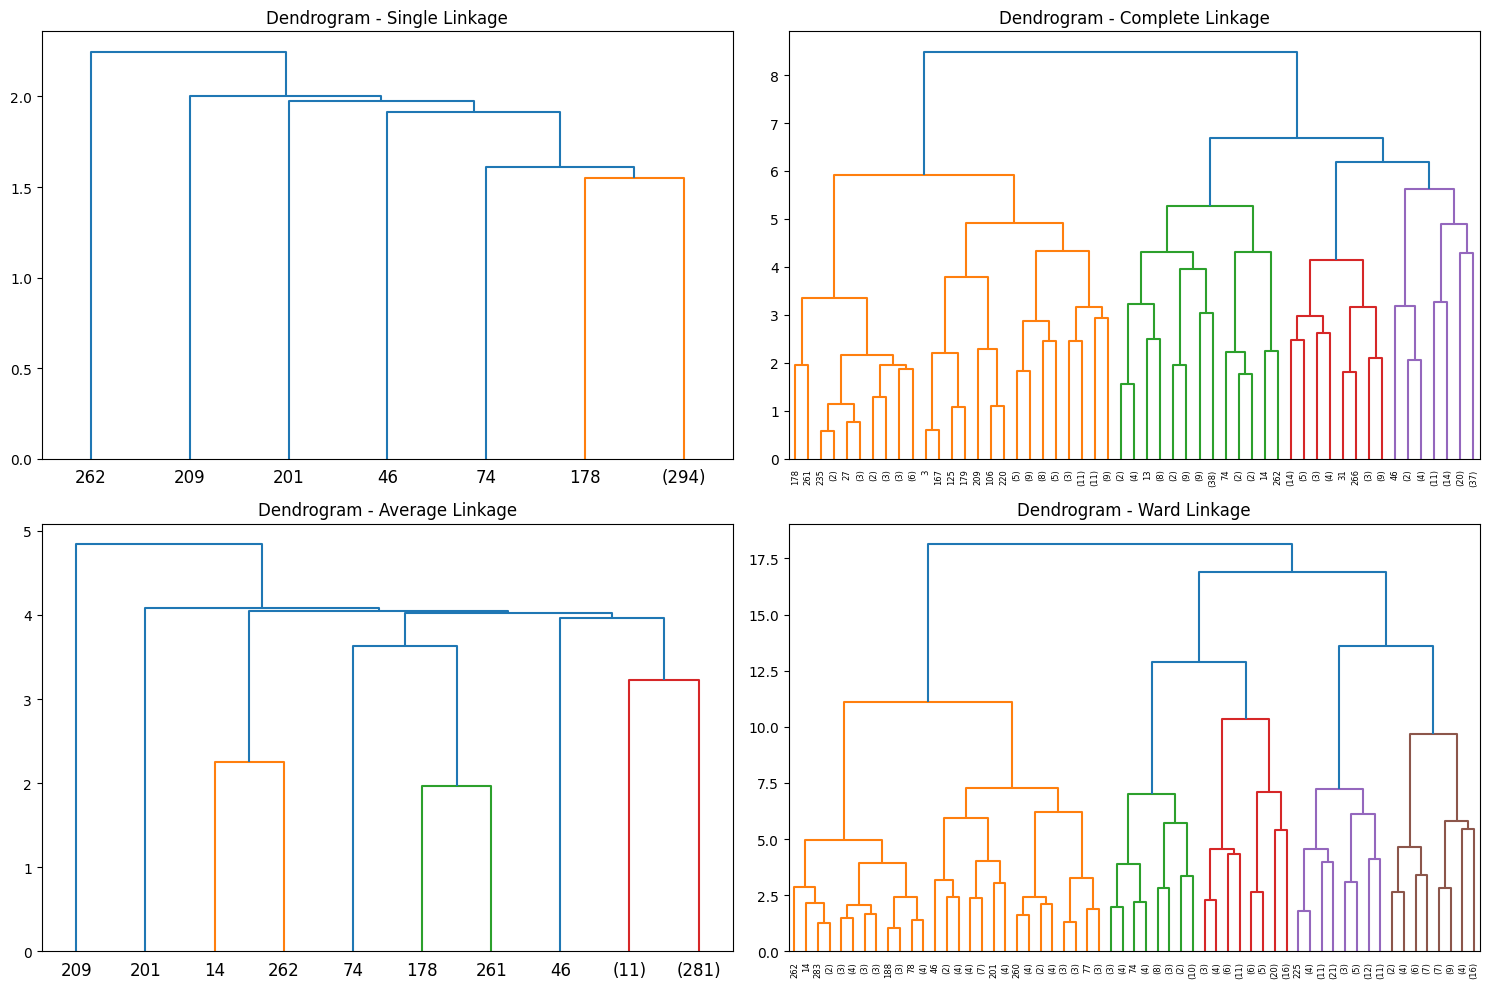

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage

linkage_methods = ['single', 'complete', 'average', 'ward']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, method in enumerate(linkage_methods):
    linkage_matrix = linkage(X_scaled, method=method)
    dendrogram(linkage_matrix, ax=axes[idx], truncate_mode='level', p=5)
    axes[idx].set_title(f'Dendrogram - {method.capitalize()} Linkage')

plt.tight_layout()
plt.show()


In [10]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')
hierarchical_clusters = hierarchical.fit_predict(X_scaled)

df['Hierarchical_Cluster'] = hierarchical_clusters


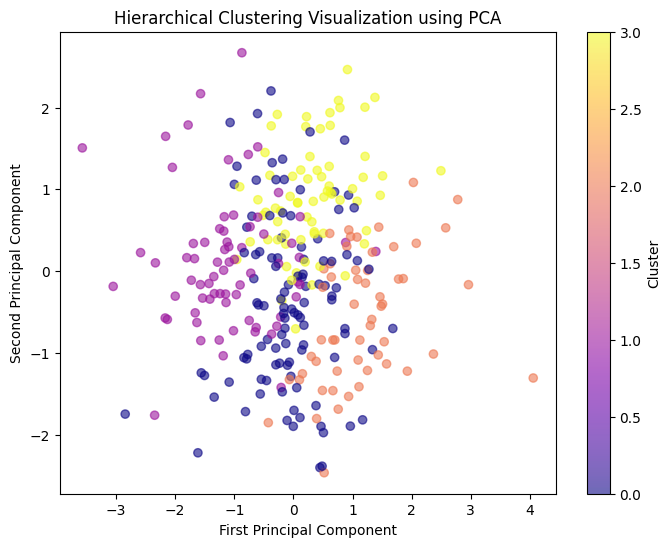

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2) # Reduce to 2 components for visualization
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=hierarchical_clusters,
            cmap='plasma',
            alpha=0.6)

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Hierarchical Clustering Visualization using PCA')
plt.colorbar(label='Cluster')
plt.show()

In [12]:
optimal_k = 4 # Based on previous KMeans analysis

for method in linkage_methods:
    agg_clustering = AgglomerativeClustering(
        n_clusters=optimal_k,
        linkage=method
    )
    agg_labels = agg_clustering.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, agg_labels)
    print(f"{method.capitalize()} Linkage - Silhouette Score: {sil_score:.3f}")

Single Linkage - Silhouette Score: 0.234
Complete Linkage - Silhouette Score: 0.130
Average Linkage - Silhouette Score: 0.214
Ward Linkage - Silhouette Score: 0.128


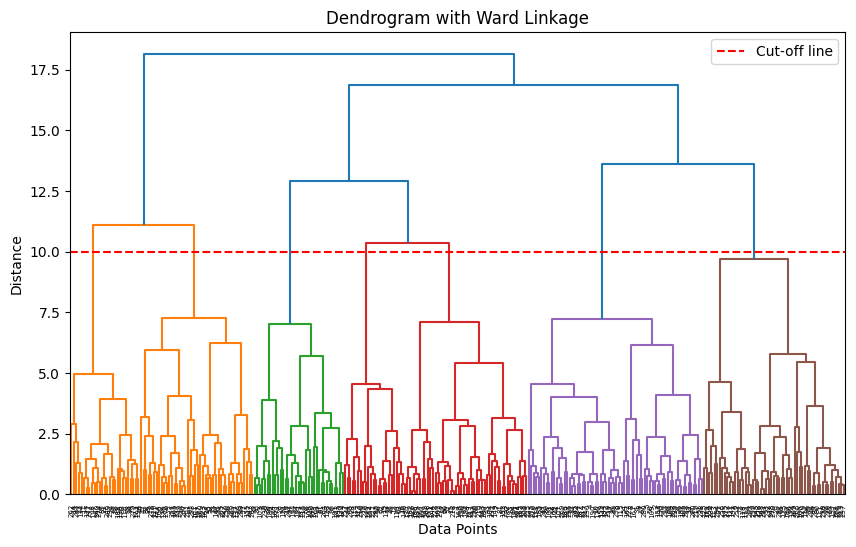

In [13]:
linkage_matrix = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix)
plt.axhline(y=10, color='r', linestyle='--', label='Cut-off line')
plt.title('Dendrogram with Ward Linkage')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.legend()
plt.show()

In [14]:
import time

# K-Means
start_time = time.time()
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_time = time.time() - start_time

# Hierarchical
start_time = time.time()
hierarchical = AgglomerativeClustering(
    n_clusters=optimal_k, linkage='ward'
)
hierarchical_labels = hierarchical.fit_predict(X_scaled)
hierarchical_time = time.time() - start_time

In [15]:
df['KMeans_Cluster'] = kmeans_labels
df['Hierarchical_Cluster'] = hierarchical_labels


In [16]:
kmeans_centers = scaler.inverse_transform(kmeans.cluster_centers_)


In [17]:
print("Hierarchical Cluster Analysis:")
for i in range(optimal_k):
    cluster_data = df[df['Hierarchical_Cluster'] == i]
    print(f"\nCluster {i} (Count: {len(cluster_data)}):")
    print(cluster_data.describe().loc[['mean', 'std']])

Hierarchical Cluster Analysis:

Cluster 0 (Count: 106):
      Annual_Income  Spending_Score        Age  Purchase_Frequency   Cluster  \
mean   41779.378495       52.246318  34.239225           12.541236  1.169811   
std    12400.829929       26.028078  10.159018            3.691124  1.206898   

      Hierarchical_Cluster  KMeans_Cluster  
mean                   0.0        1.169811  
std                    0.0        1.206898  

Cluster 1 (Count: 71):
      Annual_Income  Spending_Score        Age  Purchase_Frequency   Cluster  \
mean   44744.355285       54.305562  43.389764            4.188834  1.521127   
std    11931.322622       25.867046  11.044539            3.267760  0.954076   

      Hierarchical_Cluster  KMeans_Cluster  
mean                   1.0        1.521127  
std                    0.0        0.954076  

Cluster 2 (Count: 55):
      Annual_Income  Spending_Score        Age  Purchase_Frequency   Cluster  \
mean   67227.895715       45.395062  35.684939           13.0027

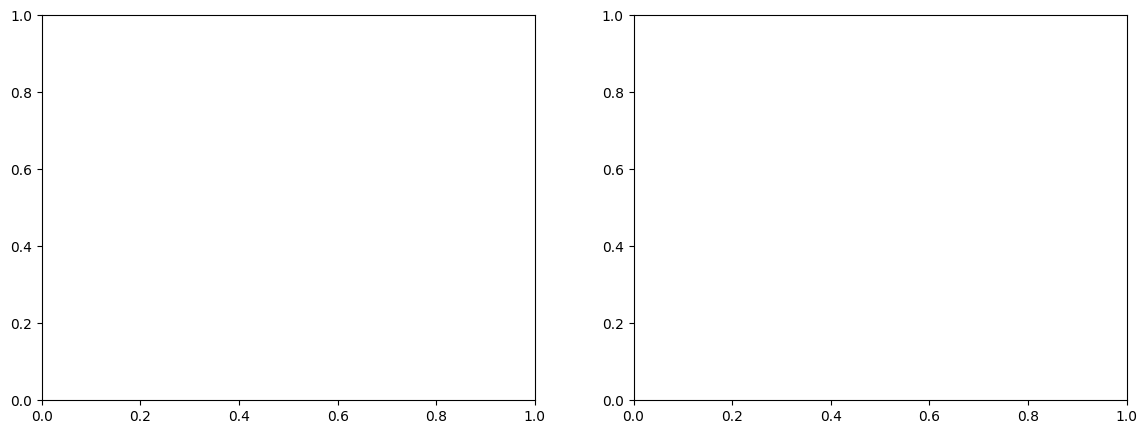

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))